Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-05-01 (+2 weeks)

==Training boolean neighbors - logged + zscore==
Epoch 1 train loss: 0.5367, val loss: 0.5264 ✓ (new best)
Epoch 2 train loss: 0.5554, val loss: 0.5012 ✓ (new best)
Epoch 3 train loss: 0.5275, val loss: 0.4949 ✓ (new best)
Epoch 4 train loss: 0.5503, val loss: 0.4793 ✓ (new best)
Epoch 5 train loss: 0.5117, val loss: 0.5001 (patience: 1/20)
Epoch 6 train loss: 0.5195, val loss: 0.4681 ✓ (new best)
Epoch 7 train loss: 0.4992, val loss: 0.4723 (patience: 1/20)
Epoch 8 train loss: 0.5010, val loss: 0.4701 (patience: 2/20)
Epoch 9 train loss: 0.5141, val loss: 0.4606 ✓ (new best)
Epoch 10 train loss: 0.5091, val loss: 0.4580 ✓ (new best)
Epoch 11 train loss: 0.5069, val loss: 0.4709 (patience: 1/20)
Epoch 12 train loss: 0.4960, val loss: 0.4662 (patience: 2/20)
Epoch 13 train loss: 0.4978, val loss: 0.4746 (patience: 3/20)
Epoch 14 train loss: 0.4762, val loss: 0.4825 (patience: 4/20)
Epoch 1

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 72/72 [00:00<00:00, 650.28it/s]


Test loss: 0.1811


(<Figure size 1600x3000 with 6 Axes>,
 array([<Axes: title={'center': 'National incidence rate (per 10000)'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 3'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 8'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 17'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 28'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 36'}, ylabel='incidence'>],
       dtype=object))

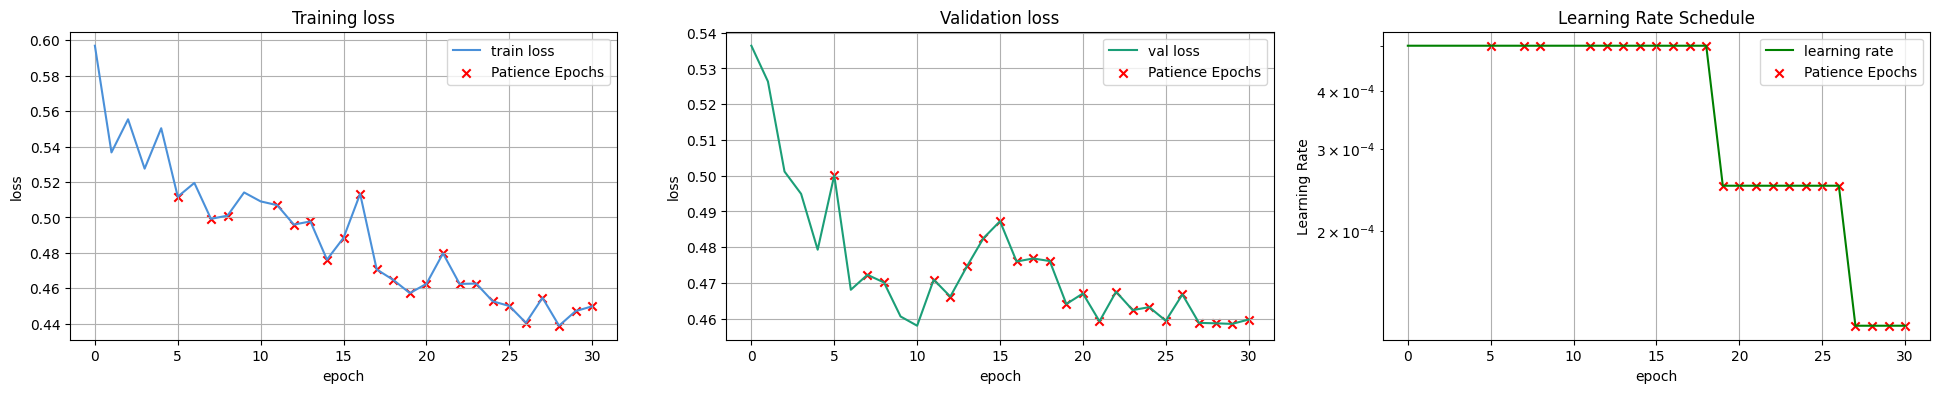

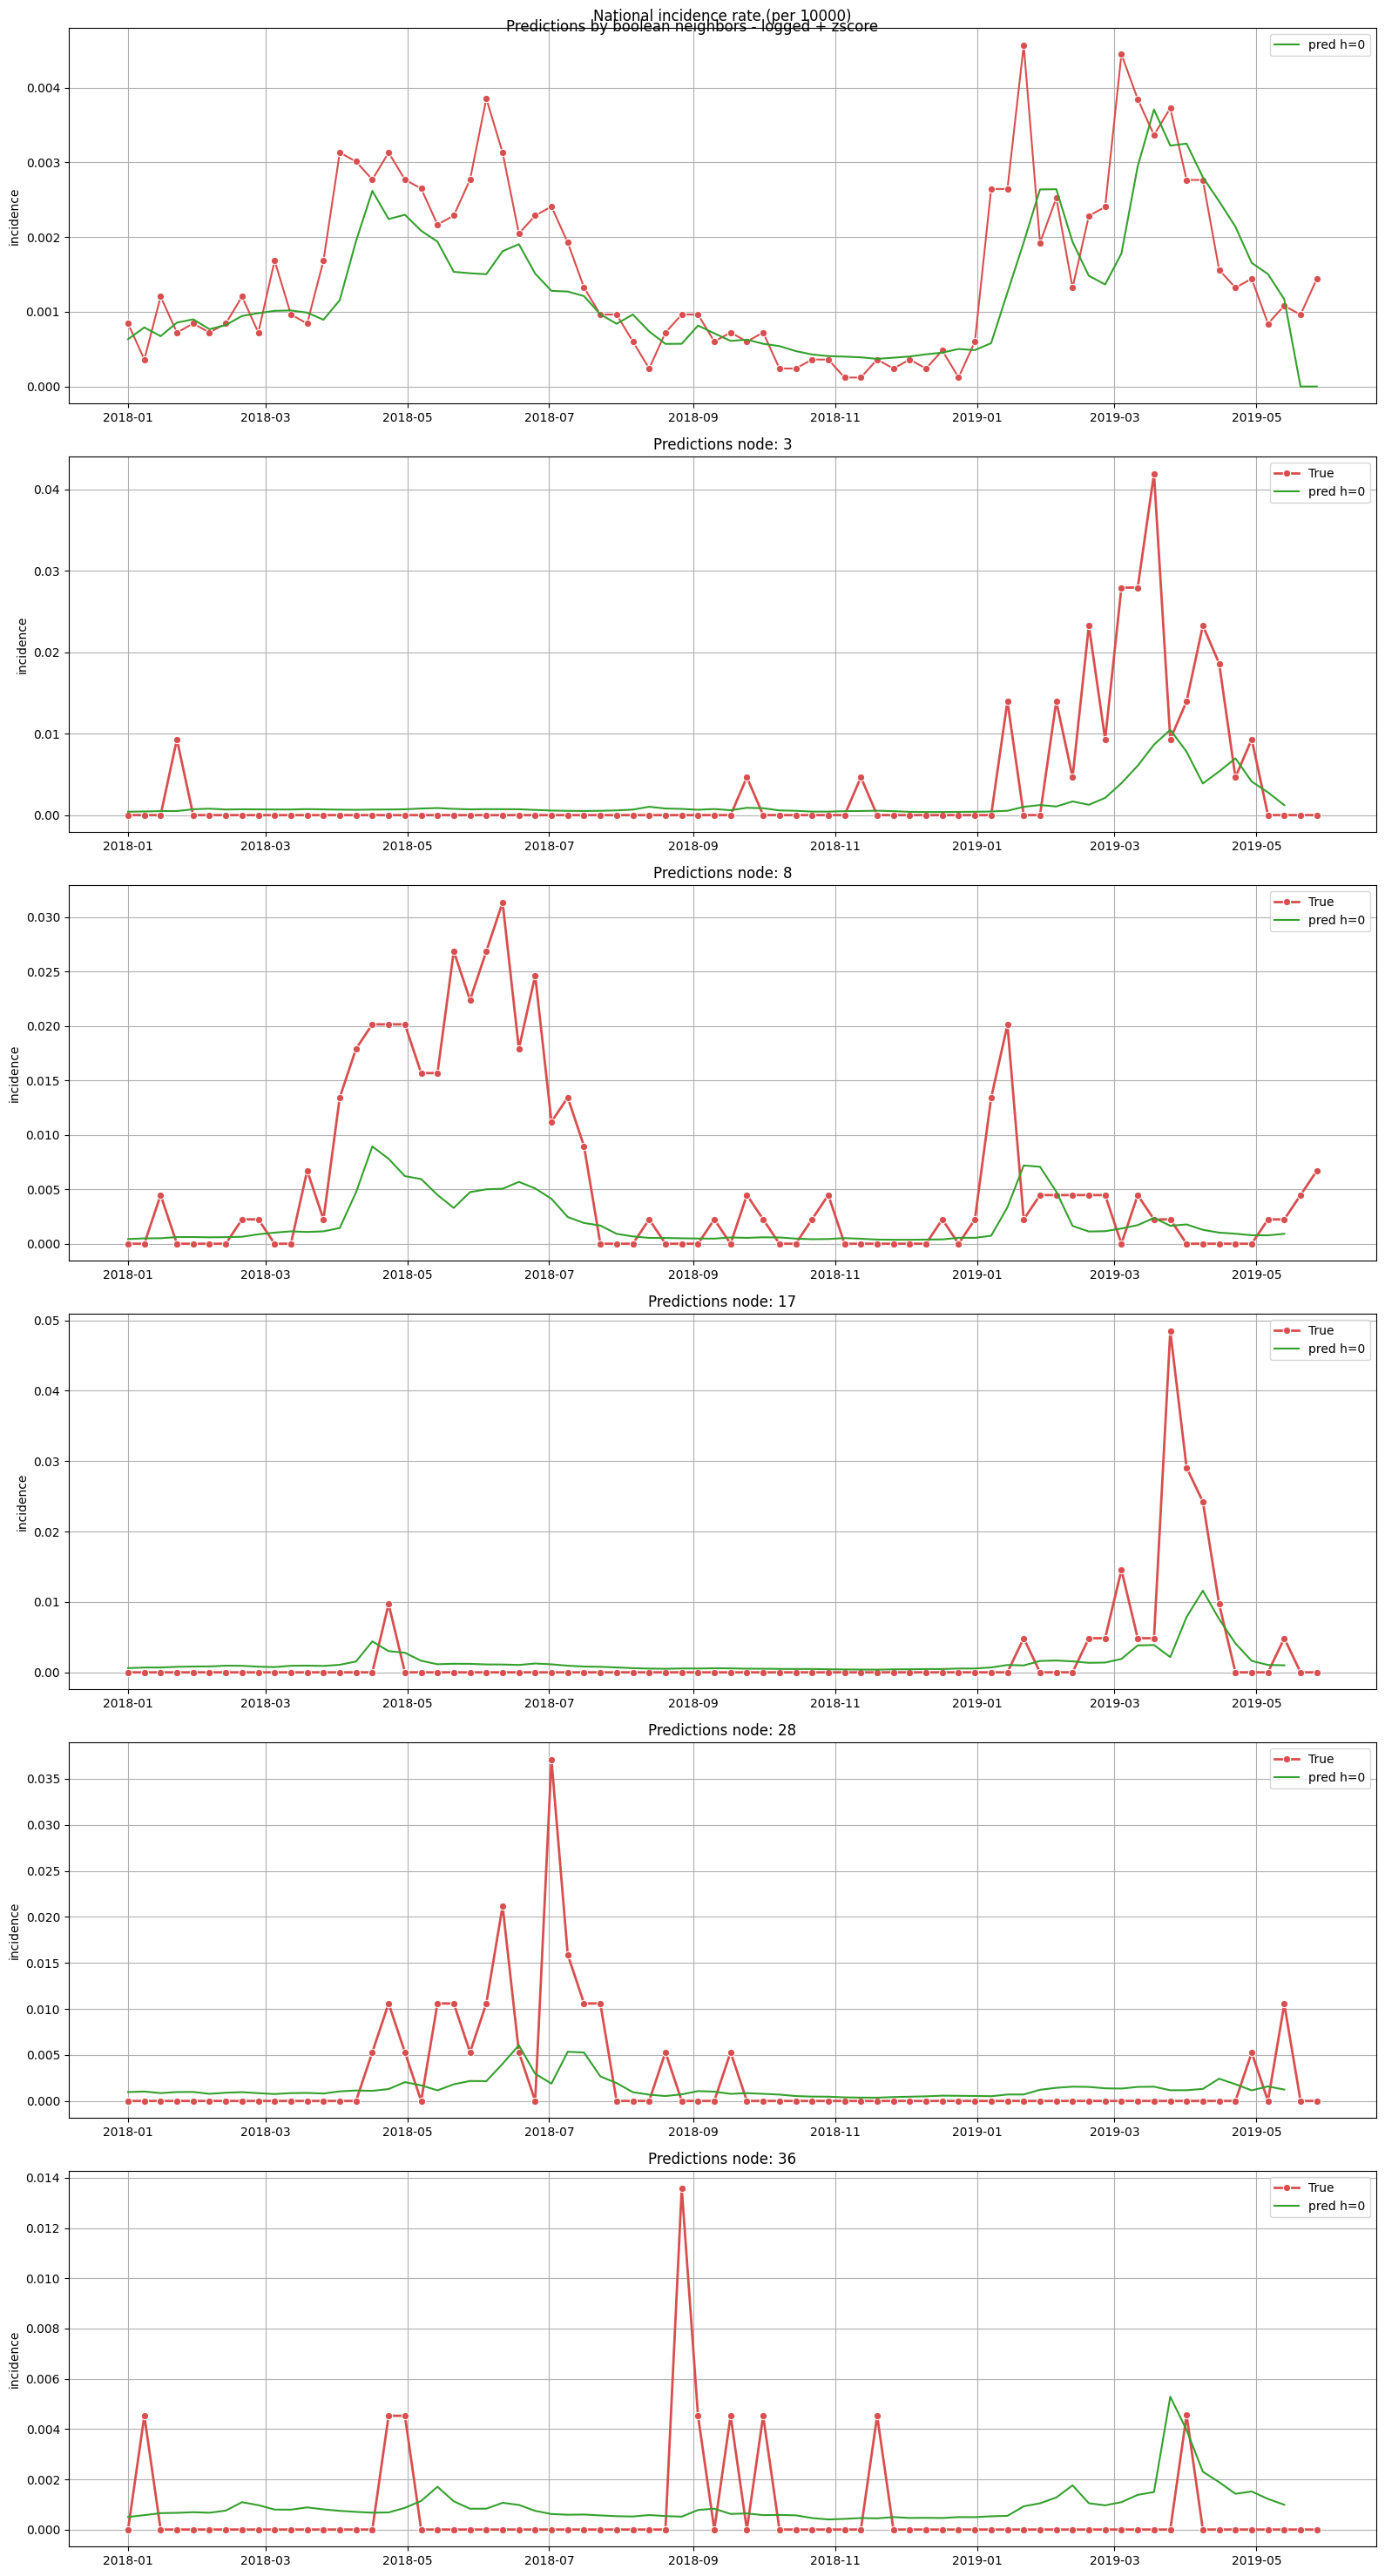

In [4]:
from src.utils import get_data_env
from src.models import SpatialGNNModel
from src.dataloading import DeepDataLoader

disease_name    = 'measles'
nuts_level      = 'nuts2'
min_date        = '2006-05-15'
max_date        = '2019-06-01'
split_trainval  = '2017-01-01'
split_valtest   = '2018-01-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lags            = 4

graphtype       = 'boolean_neighbors_self0'

# training hparams
n_epochs        = 100
lr              = 0.0005
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

epidata_loader_bn_logged = DeepDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_bn_logged.add_time_features()
epidata_loader_bn_logged.log_transform_target()
epidata_loader_bn_logged.set_splits(split_trainval, split_valtest)
epidata_loader_bn_logged.normalize()
epidata_loader_bn_logged.add_lagged_features(lags = lags)
epidata_loader_bn_logged.finalize()
epidata_loader_bn_logged.retrieve_graph(graphtype)
epidata_loader_bn_logged.construct_dataloaders()

spatial_bn = SpatialGNNModel(epidata_loader_bn_logged, name = 'boolean neighbors - logged + zscore')
spatial_bn.set_model_hparams()
spatial_bn.set_global_hparams(**global_hparams)
spatial_bn.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
spatial_bn.forecast('test')
spatial_bn.show_forecasts('test', [3,8, 17, 28, 36], target_h=0)


In [5]:
from src.graphconstruction.graphconstructor import GraphConstructor

In [31]:

graphconstruction = GraphConstructor(epidata = epidata_loader_bn_logged)
graphconstruction.generate_graph(
    method='identity', 
    self_connection='0'
    )

graphconstruction.generate_graph(
    method='boolean_neighbors', 
    self_connection='max',
)

graphconstruction.generate_graph(
    method='boolean_neighbors', 
    self_connection='0',
)
# long distance, sparse
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 3,
    alpha = 1,
    decay = 1,
    scaling_method='rowwise'
)

# long distance, dense
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 7,
    alpha = 1,
    decay = 1,
    scaling_method='rowwise',
    name_addition='2'
)

# more locally oriented, sparse
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 3,
    alpha = 2,
    decay = 1,
    scaling_method='rowwise',
    name_addition='3'
)


# more locally oriented, denser
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 7,
    alpha = 2,
    decay = 1,
    scaling_method='rowwise',
    name_addition='4'
)

# more locally oriented, denser
graphconstruction.generate_graph(
    method='mesh', 
)


# graphconstruction.generate_graph(
#     method='commuter', 
#     self_connection='0',
#     commuter_type = 'static',
#     commuting_threshold = 1000,
#     top_k = 4,
#     scaling_method='rowwise',
#     name_addition='1'
# )

# graphconstruction.generate_graph(
#     method='commuter', 
#     self_connection='mean',
#     commuter_type = 'static',
#     commuting_threshold = 1000,
#     top_k = 4,
#     scaling_method='rowwise',
#     name_addition='2'
# )

# graphconstruction.generate_graph(
#     method='commuter', 
#     self_connection='0',
#     commuter_type = 'static',
#     commuting_threshold = 1000,
#     scaling_method='rowwise',
#     name_addition='3'
# )

# graphconstruction.generate_graph(
#     method='commuter', 
#     self_connection='mean',
#     commuter_type = 'static',
#     commuting_threshold = 1000,
#     scaling_method='rowwise',
#     name_addition='4'
# )

graphconstruction.rename_graph('identity_self0',                'identity_graph')
graphconstruction.rename_graph('boolean_neighbors_selfmax',     'boolean_neighbors_self')
graphconstruction.rename_graph('boolean_neighbors_self0',       'boolean_neighbors_nonself')
graphconstruction.rename_graph('gravity_model_self0_rowwise',   'gravity1')
graphconstruction.rename_graph('gravity_model_2_self0_rowwise', 'gravity2')
graphconstruction.rename_graph('gravity_model_3_self0_rowwise', 'gravity3')
graphconstruction.rename_graph('gravity_model_4_self0_rowwise', 'gravity4')
# graphconstruction.rename_graph('commuter_1_self0_rowwise',      'commuter1')
# graphconstruction.rename_graph('commuter_2_selfmean_rowwise',   'commuter2')
# graphconstruction.rename_graph('commuter_3_self0_rowwise',      'commuter3')
# graphconstruction.rename_graph('commuter_4_selfmean_rowwise',   'commuter4')
graphconstruction.rename_graph('mesh_selfmean', 'mesh')
graphconstruction.save_graph('all')

✓ graph generated: identity_self0
✓ graph generated: boolean_neighbors_selfmax
✓ graph generated: boolean_neighbors_self0
✓ graph generated: gravity_model_self0_rowwise
✓ graph generated: gravity_model_2_self0_rowwise
✓ graph generated: gravity_model_3_self0_rowwise
✓ graph generated: gravity_model_4_self0_rowwise
✓ graph generated: mesh_selfmean
identity_self0 has been replaced by identity_graph
boolean_neighbors_selfmax has been replaced by boolean_neighbors_self
boolean_neighbors_self0 has been replaced by boolean_neighbors_nonself
gravity_model_self0_rowwise has been replaced by gravity1
gravity_model_2_self0_rowwise has been replaced by gravity2
gravity_model_3_self0_rowwise has been replaced by gravity3
gravity_model_4_self0_rowwise has been replaced by gravity4
mesh_selfmean has been replaced by mesh
✓ graph saved: edge index identity_graph saved to data/graphs/nuts2
✓ graph saved: edge weight identity_graph saved to data/graphs/nuts2
✓ graph saved: edge index boolean_neighbors_

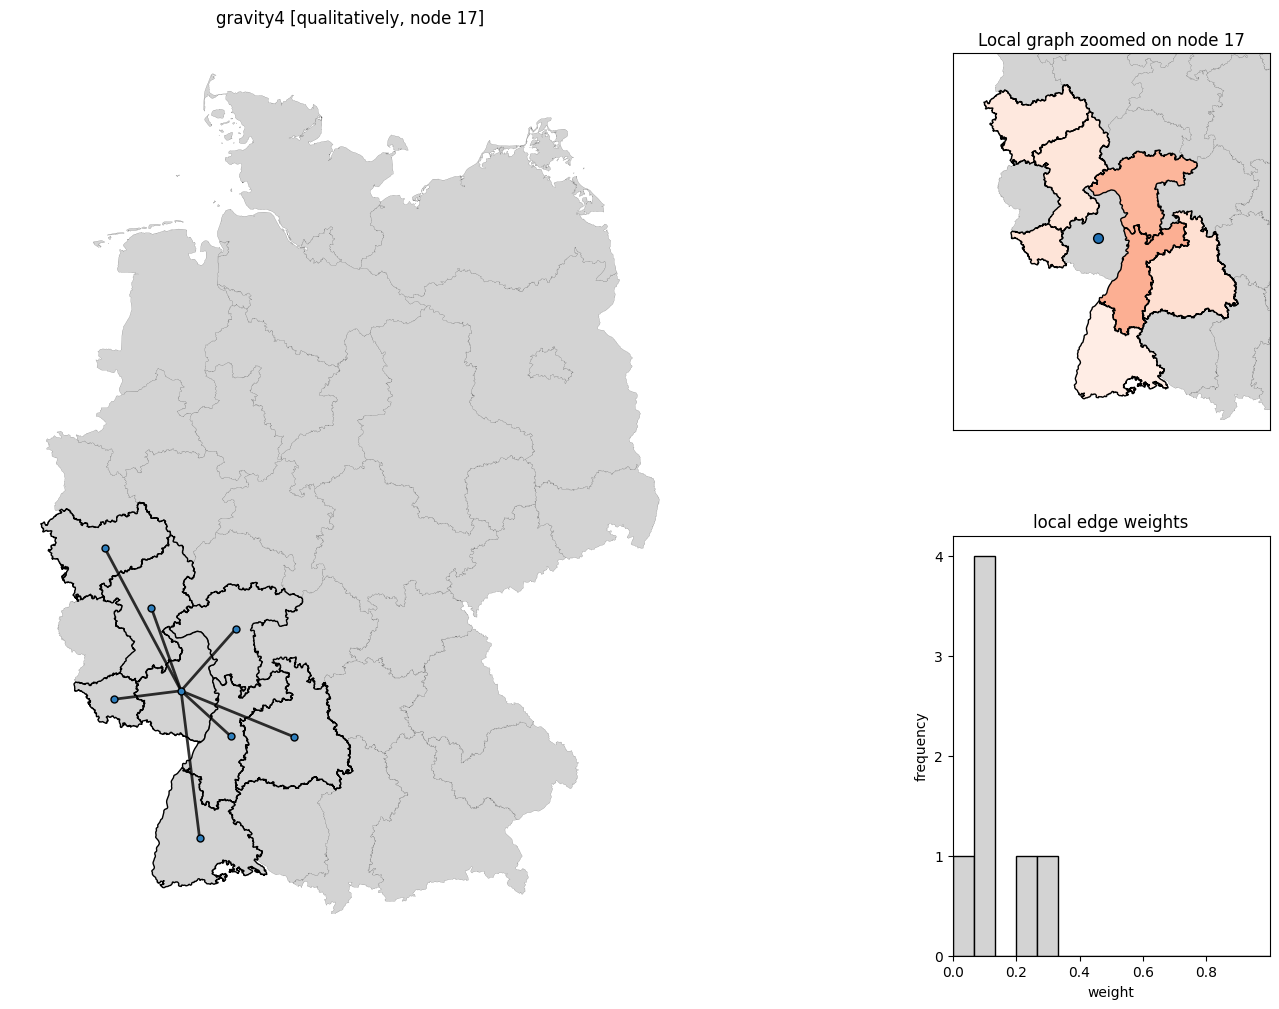

In [28]:
graphconstruction.preview_graph('gravity4',node_idx = 17)